In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary tools for NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1-4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading omw-1-4: Package 'omw-1-4' not found in
[nltk_data]     index


False

In [13]:
# Load the training data
df = pd.read_csv('/kaggle/input/learn-ai-bbc/BBC News Train.csv')

# Let's see what the first few rows look like
print(df.head())

   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


Dataset Shape: (1490, 3)

First 5 Rows:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


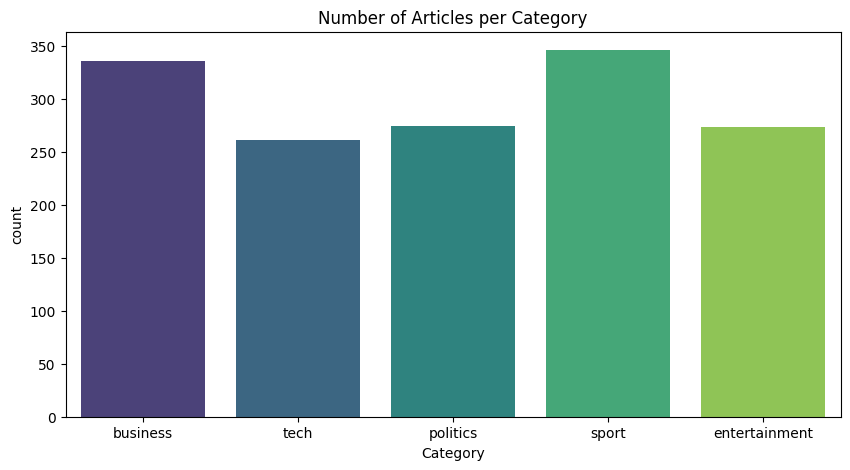


Sample Tech Article Snippet:
lifestyle  governs mobile choice  faster  better or funkier hardware alone is not going to help phone firms sell more handsets  research suggests.  instead  phone firms keen to get more out of their customers should not just be pushing the technology for its own sake. consumers are far more interest...


In [14]:
# 2. Basic Info
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())

# 3. Check for Category Balance
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Category', palette='viridis')
plt.title('Number of Articles per Category')
plt.show()

# 4. See a sample article
print("\nSample Tech Article Snippet:")
print(df[df['Category'] == 'tech']['Text'].iloc[0][:300] + "...")

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize and remove stopwords + Lemmatize
    tokens = text.split()
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return " ".join(clean_tokens)

# Apply the cleaning function to our text column
df['Text_Clean'] = df['Text'].apply(clean_text)

# Let's see the difference
print("Original Text Sample:")
print(df['Text'].iloc[0][:150])
print("\nCleaned Text Sample:")
print(df['Text_Clean'].iloc[0][:150])

Original Text Sample:
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whist

Cleaned Text Sample:
worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company whistleblower first witness cy


In [16]:
from sklearn.model_selection import train_test_split

# X is our cleaned text, y is our category 
X = df['Text_Clean']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1192
Testing samples: 298


Accuracy Score: 95.97%

Classification Report:
               precision    recall  f1-score   support

     business       0.95      0.97      0.96        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.91      0.95        58

     accuracy                           0.96       298
    macro avg       0.96      0.96      0.96       298
 weighted avg       0.96      0.96      0.96       298



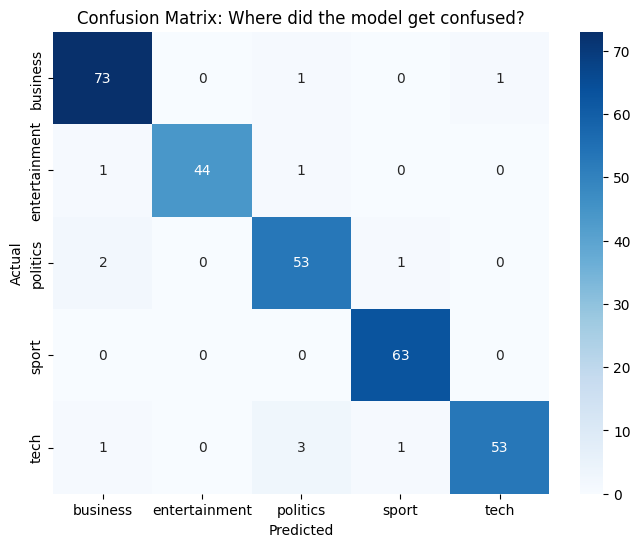

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Create a Pipeline: This does Vectorization (TF-IDF) then Training (Naive Bayes)
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3))), # Uses single words and pairs of words
    ('nb', MultinomialNB())
])

# 2. Step 5: Train the model
model_pipeline.fit(X_train, y_train)

# 3. Step 6: Evaluation (The Final Exam)
y_pred = model_pipeline.predict(X_test)

# Print results
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model_pipeline.classes_, yticklabels=model_pipeline.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where did the model get confused?')
plt.show()

In [18]:
# 1. Load the unlabeled test data
test_df = pd.read_csv('/kaggle/input/learn-ai-bbc/BBC News Test.csv')

# 2. Clean the new articles
test_df['Text_Clean'] = test_df['Text'].apply(clean_text)

# 3. Use your trained pipeline to predict categories
test_predictions = model_pipeline.predict(test_df['Text_Clean'])

# 4. Prepare the submission file (Kaggle usually wants 'ArticleId' and 'Category')
submission = pd.DataFrame({
    'ArticleId': test_df['ArticleId'],
    'Category': test_predictions
})

# 5. Save to a CSV file in your Kaggle output folder
submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
print(submission.head())

Submission file created successfully!
   ArticleId  Category
0       1018     sport
1       1319      tech
2       1138     sport
3        459  business
4       1020     sport
